# Automated 2D affine drift correction — silicon

Same **automated** affine recipe as the Co₃O₄ template
(`2d_affine_co3o4.ipynb`). Only the data paths differ.

- `correct_affine()` chooses search settings for you.
- Display knobs on `plot_combined` / `show` match the Co₃O₄ tutorial.

Set `INTERACTIVE = False` in the device cell for static/report rendering.

Want more control? Use the matching **`advanced/2d_affine_explicit_*.ipynb`** notebook.


## Environment

Install the reviewed paper API and latest published `quantem.widget` release
candidate. One notebook supports both interactive and static/report output:

```bash
python -m pip install --upgrade \
  "git+https://github.com/bobleesj/quantem.git@drift-paper"
python -m pip install --pre --upgrade \
  --index-url https://test.pypi.org/simple \
  --extra-index-url https://pypi.org/simple quantem.widget
```


## Data

Download the [raw silicon data](https://drive.google.com/drive/folders/12pumbdYgg2ZYuIi56bzp5lLYJt3__evj?usp=sharing) and place the files in
`data/silicon/`. The shared folder contains only the original
acquisitions; this notebook generates its result locally.


## Device


In [1]:
from pathlib import Path

import quantem.widget as qw
from quantem.imaging import DriftCorrection

# Raw EMDs + AutoSerialized result live together under DATA.
# Point DATA at your folder to run the same tutorial on your pair.
DATA = Path("data/silicon")
RESULT = DATA / "drift.zip"

# Interactive is the recommended default. False uses static/report rendering.
INTERACTIVE = True
VIEW_MODE = "interactive" if INTERACTIVE else "static"

# QuantEM selects CUDA / MPS / CPU automatically.
qw.profile()


quantem.widget  0.0.1rc36
  install       published package
quantem.gpu     0.0.1rc6
  install       editable checkout
quantem         0.1.9
torch           2.13.0  device=cuda (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition)
GPUs            1 visible (CUDA_VISIBLE_DEVICES=1)
  GPU0           23.5 used / 102 GB  (78 free)
  torch pool    0.0 live / 0.0 reserved GB
python          3.14.6


## Load the orthogonal scans

Replace the two filenames with your 0° / 90° (or 0° / −90°) EMDs. Scan rotation
is read from Velox metadata — do not hardcode angles for EMD files.


In [2]:
drift = DriftCorrection.from_emd(
    DATA / "0041_20260515_1130_15.0_Mx_6.74_nm_Nano_HAADF.emd",
    DATA / "0042_20260515_1130_15.0_Mx_6.74_nm_Nano_HAADF.emd",
    verbose=False,
)


## Correct affine drift (automatic)

No search parameters: QuantEM runs the automatic image-pyramid search
(padding, bounds, downsampling, drift-rate range, refinement).

Keep the solve quiet; inspect with `plot_combined` / `report` / `show` below.

Want more control? Use the matching **`advanced/2d_affine_explicit_*.ipynb`** notebook.


In [3]:
drift.correct_affine(
    # display during solve (optional; inspection cells below are preferred)
    show_combined=False,  # RGB merge when this cell finishes
    show_scans=False,     # each warped scan
    show_knots=False,     # knot overlay on those plots
    show_knot_plot=False, # separate knot trajectory figure
    show_report=False,    # NCC table here (report() cell below)
    verbose=False,        # candidate progress + top-5 vectors
)


## Check registration — `plot_combined`

Interactive **red / green** overlay (yellow ≈ registered). Contrast is built into
the overlay; only panel size and optional FFT are usual knobs.


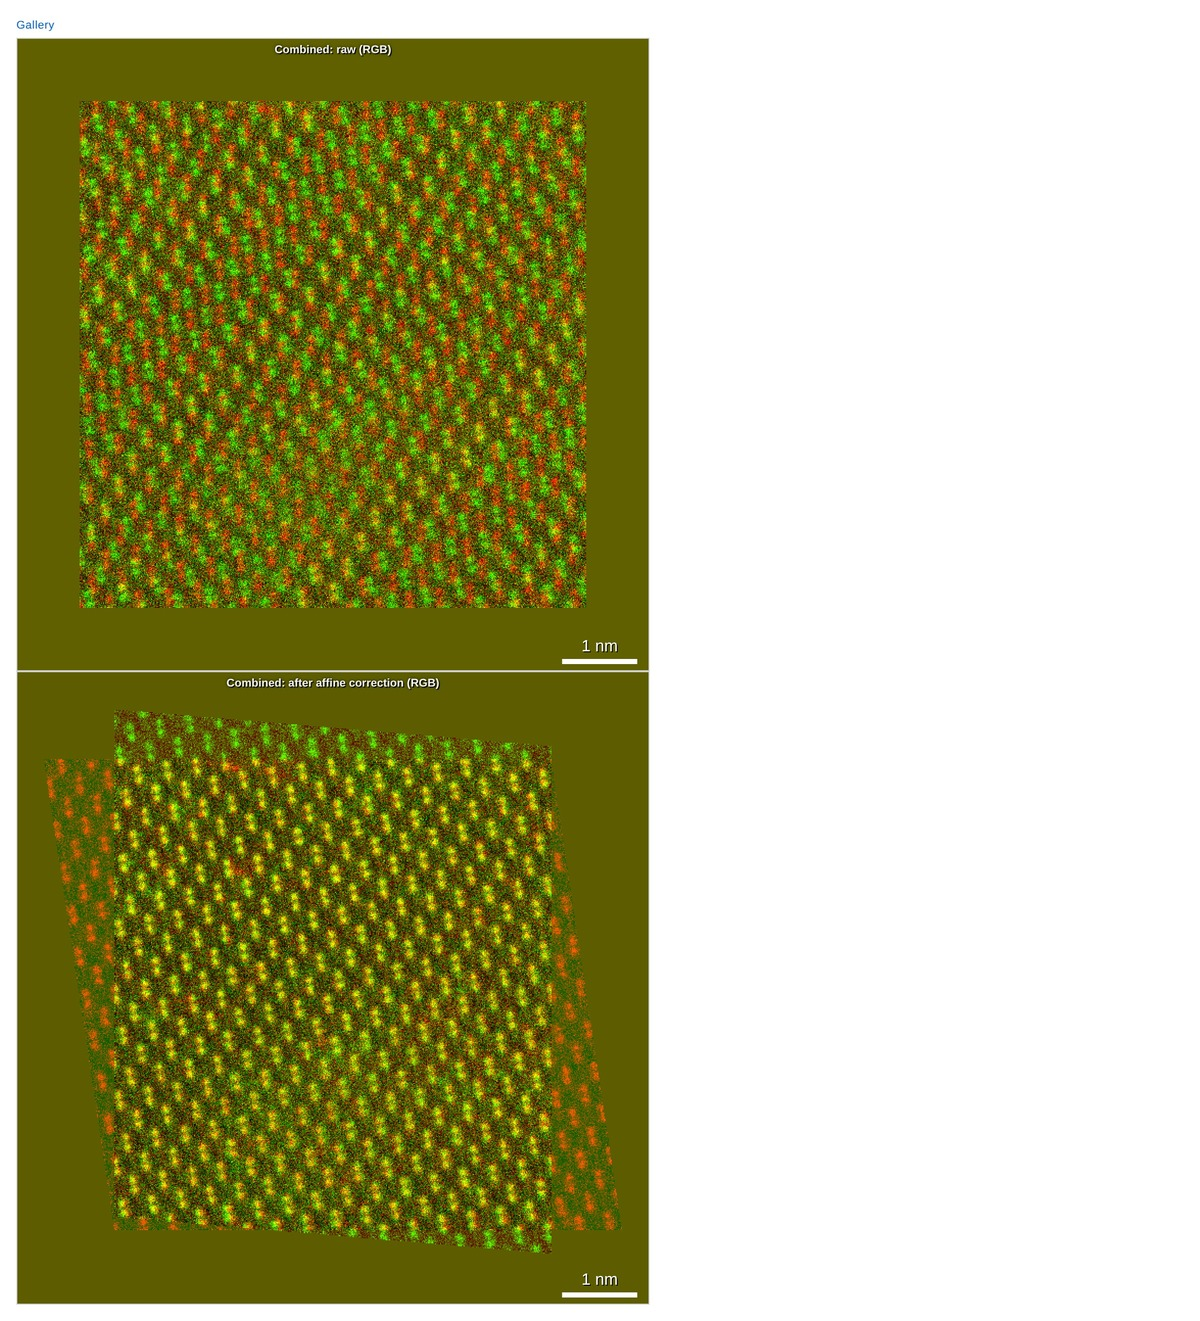

In [4]:
drift.plot_combined(
    stage=("initial", "affine"),  # before | after side by side
    # stage="affine",             # after only
    interactive=INTERACTIVE,       # linked widget | static Matplotlib
    width=620,                    # panel width px — 400 | 620 | 900
    # show_fft=False,             # FFT under each panel
    # zoom=1.0,                   # start zoom (>1 zooms in)
    # center=(0.0, 0.0),          # fractional (row, col) pan in [-0.5, 0.5]
)


## Scores — `report()`

Regional NCC on the common-coverage mask (before vs affine). Same table used
in the paper workflows.


In [5]:
drift.report()


,Common NCC,Top third,Middle third,Bottom third,Coverage
Mutual stage,,,,,
before,-0.000303,0.001657,-0.000314,-0.002675,0.794359
affine,0.392485,0.419296,0.401792,0.354213,0.794359


## Corrected result — `show()`

Grayscale gallery of the product (not the RGB registration check). Safe knobs
below are display-only.


  Display bin 3×: 2560×2560 → 853×853 (16 MB preview; full-res detail streams on zoom)


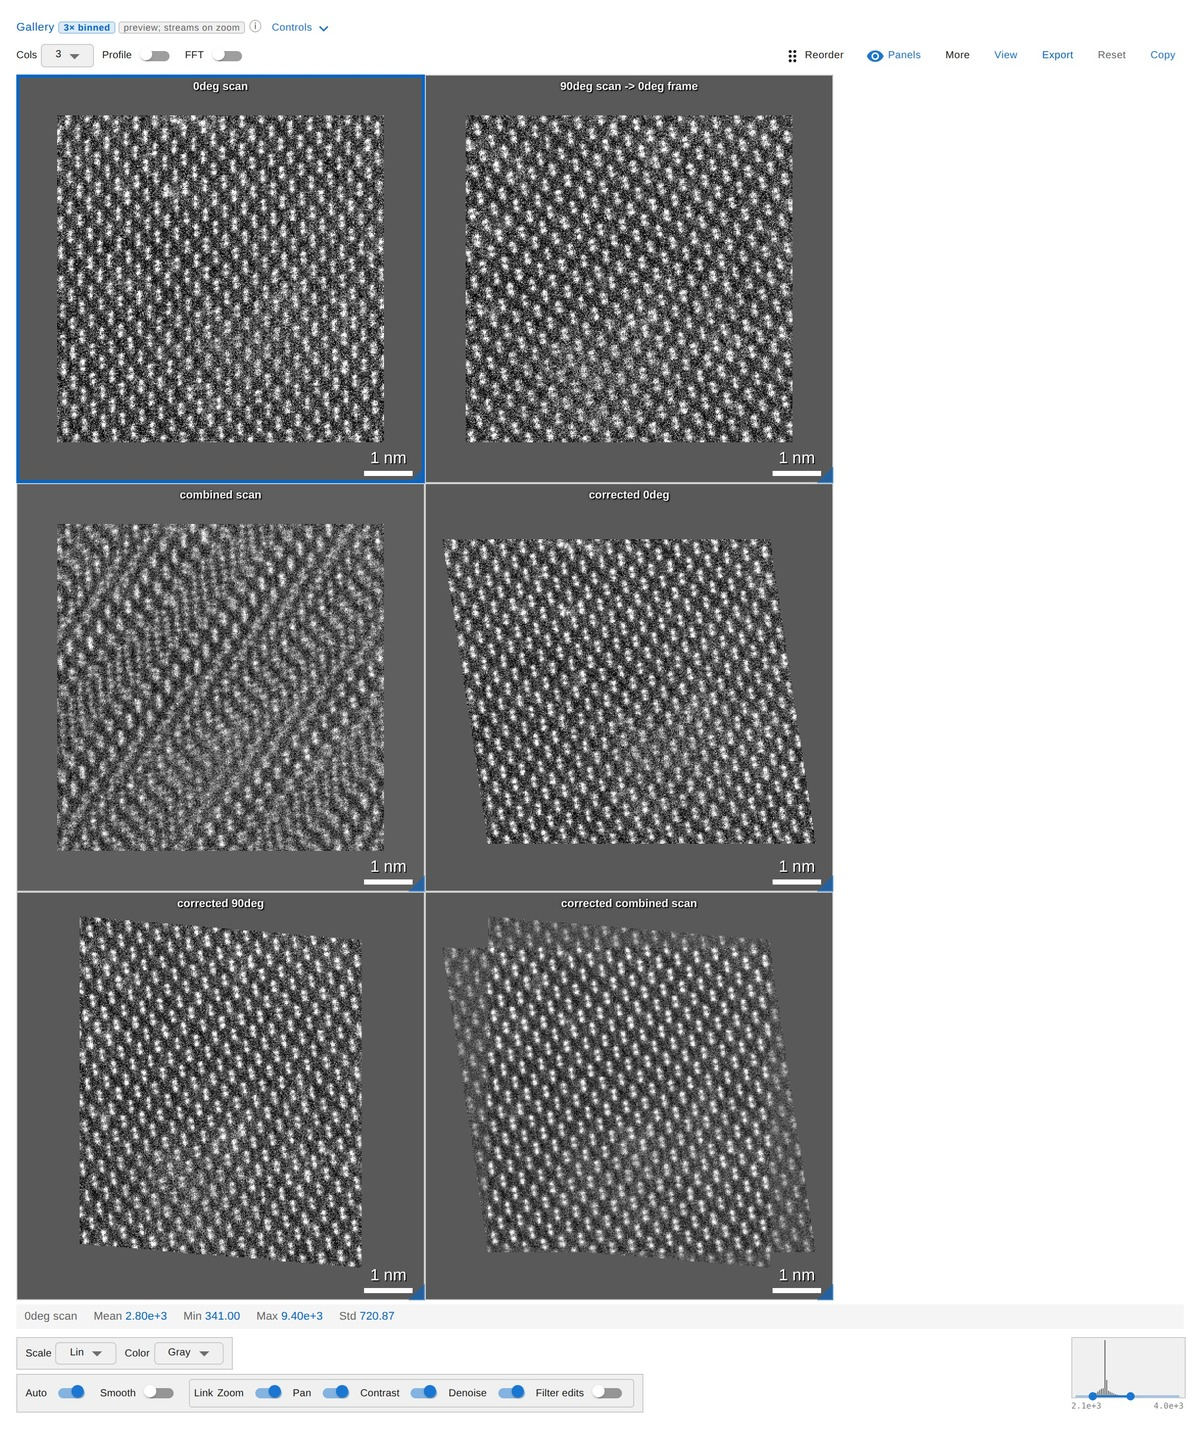

In [6]:
drift.show(
    mode=VIEW_MODE,
    cmap="gray",           # gray | inferno | viridis | plasma
    auto_contrast=True,    # percentile clim | full range
    link_contrast=True,    # shared clim across panels
    smooth=False,          # nearest | interpolated
    show_fft=False,        # FFT companion panels
    # zoom=1.0,            # start zoom (>1 zooms in)
    # size=400,            # panel size px
    # center=(0.0, 0.0),   # fractional (row, col) pan in [-0.5, 0.5]
)


## Save the full solved object

AutoSerialize the entire `DriftCorrection` next to the raw EMDs. Figure notebooks
load this zip; they do not re-run correction.


In [7]:
DATA.mkdir(parents=True, exist_ok=True)
drift.save(RESULT, mode="o")
print(f"Saved: {RESULT}")


Saved: data/silicon/drift.zip


## Next steps

- **Your data:** change `DATA` and the two EMD filenames; re-run.
- **More control:** the matching `advanced/2d_affine_explicit_*.ipynb`
- **Non-rigid polish (WS₂ / Fig 3):** `2d_nonrigid_ws2.ipynb`

Regenerate this notebook source:

```bash
python tutorials/template/generate_affine_tutorial.py --preset silicon --no-execute
```
